<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/climas_brasil_koppen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Bibliotecas
___

In [22]:
# =========================================================
# REQUIRED LIBRARIES
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geobr
from geobr import read_municipality
from matplotlib.colors import ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D
import unicodedata

import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

import warnings
from cartopy.io import DownloadWarning

## 2. Carregar o CSV de classificação

In [23]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/koppen_municipios_preenchido.csv"
df_koppen = pd.read_csv(url, sep=",")
df_koppen

,code_muni,name_muni,abbrev_state,classe_koppen,classe_koppen_codigo,precip_anual_mm,precip_mes_mais_seco_mm,temp_anual_c,temp_mes_mais_frio_c,temp_mes_mais_quente_c,preenchido_por_vizinho
0,1100015.0,Alta Floresta d'Oeste,RO,Aw,4.0,1543.700000,6.066667,25.139167,23.733333,26.008333,False
1,1100023.0,Ariquemes,RO,Aw,4.0,2159.366667,6.533333,25.682639,24.898333,26.316667,False
2,1100031.0,Cabixi,RO,Aw,4.0,1641.600000,11.300000,25.445833,23.531667,26.665000,False
3,1100049.0,Cacoal,RO,Aw,4.0,1965.000000,8.100000,24.789722,23.655000,25.720000,False
4,1100056.0,Cerejeiras,RO,Aw,4.0,1522.100000,8.900000,25.460278,23.668333,26.630000,False
...,...,...,...,...,...,...,...,...,...,...,...
5565,5222005.0,Vianópolis,GO,Aw,4.0,1547.366667,2.466667,21.919444,19.448333,24.048333,False
5566,5222054.0,Vicentinópolis,GO,Aw,4.0,1560.700000,4.200000,24.239583,21.793333,26.313333,False
5567,5222203.0,Vila Boa,GO,Aw,4.0,1258.433333,0.966667,24.911528,22.406667,27.048333,False
5568,5222302.0,Vila Propício,GO,Aw,4.0,1466.633333,1.933333,24.155972,21.713333,26.180000,False


### 3. Legenda, paleta e utilitários

In [24]:
KOPPEN_LABELS = {
    1:'Af',2:'Am',3:'As',4:'Aw',5:'BSh',6:'BSk',7:'BWh',8:'BWk',
    9:'Cfa',10:'Cfb',11:'Cfc',12:'Csa',13:'Csb',14:'Csc',15:'Cwa',16:'Cwb',17:'Cwc',
    18:'Dfa',19:'Dfb',20:'Dfc',21:'Dfd',22:'Dsa',23:'Dsb',24:'Dsc',25:'Dsd',
    26:'Dwa',27:'Dwb',28:'Dwc',29:'Dwd',30:'ET',31:'EF',
}
KOPPEN_COLORS = {
    1:'#0000FF',2:'#0078FF',3:'#46A0FF',4:'#96C8FF',5:'#F5A623',6:'#FFDA8C',7:'#FF0000',8:'#FF9696',
    9:'#C8FF50',10:'#64FF50',11:'#32C800',12:'#FFFF00',13:'#C8C800',14:'#969600',
    15:'#C8FFC8',16:'#96FF96',17:'#64C864',18:'#B4A0FA',19:'#8C78F0',20:'#6450E6',21:'#3C2CB4',
    22:'#E0C8FF',23:'#C8A0FF',24:'#B478FF',25:'#9650FF',26:'#D2D2FF',27:'#AAAAFF',28:'#8282FF',29:'#5A5AFF',
    30:'#B4B4B4',31:'#696969',
}

def normalize(s):
    if pd.isna(s):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', str(s)) if not unicodedata.combining(c)).upper().strip()

STATE_ABBR = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPA':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARA':'CE',
    'DISTRITO FEDERAL':'DF','ESPIRITO SANTO':'ES','GOIAS':'GO','MARANHAO':'MA','MATO GROSSO':'MT',
    'MATO GROSSO DO SUL':'MS','MINAS GERAIS':'MG','PARA':'PA','PARAIBA':'PB','PARANA':'PR',
    'PERNAMBUCO':'PE','PIAUI':'PI','RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN',
    'RIO GRANDE DO SUL':'RS','RONDONIA':'RO','RORAIMA':'RR','SANTA CATARINA':'SC','SAO PAULO':'SP',
    'SERGIPE':'SE','TOCANTINS':'TO',
}

In [25]:
municipios_gdf = geobr.read_municipality(code_muni='all', year=2020).to_crs(epsg=4326)
estados_gdf = geobr.read_state(code_state='all', year=2020).to_crs(epsg=4326)
print(f'geobr trouxe {len(municipios_gdf)} municípios e {len(estados_gdf)} estados.')

# ponto representativo interno (garantidamente dentro do polígono, mesmo em formatos côncavos)
municipios_gdf['pt_interno'] = municipios_gdf.geometry.representative_point()
municipios_gdf['lon_c'] = municipios_gdf['pt_interno'].x
municipios_gdf['lat_c'] = municipios_gdf['pt_interno'].y
municipios_gdf['municipio_norm'] = municipios_gdf['name_muni'].apply(normalize)

geobr trouxe 5570 municípios e 27 estados.


## 4. Funções de plotagem (estilo cartopy padrão)

In [26]:
def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))

In [27]:
def plot_koppen(gdf, savepath='koppen_municipios.png'):
    classes = sorted(gdf['classe_koppen_codigo'].dropna().unique().astype(int))
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, 'Köppen-Geiger')
    for c in classes:
        gdf[gdf['classe_koppen_codigo'] == c].plot(ax=ax, color=KOPPEN_COLORS[c], edgecolor='none',
                                                     transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    total = gdf['classe_koppen_codigo'].notna().sum()
    cont = gdf['classe_koppen_codigo'].value_counts()
    patches = [mpatches.Patch(facecolor=KOPPEN_COLORS[c], edgecolor='black', linewidth=0.4,
                               label=f'{KOPPEN_LABELS[c]}  ({100*cont.get(c,0)/total:.1f}%)') for c in classes]
    ax.legend(handles=patches, title='Köppen-Geiger', loc='upper right', frameon=True, fontsize=8.5)
    ax.set_title('Classificação de Köppen-Geiger', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout(); plt.savefig(savepath, dpi=600, bbox_inches='tight'); plt.show()

In [28]:
def plot_continua(gdf, coluna, titulo, unidade, cmap_nome, savepath=None):
    dados = gdf.dropna(subset=[coluna])
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    vmin, vmax = dados[coluna].quantile([0.02, 0.98])   # evita outlier esticar a escala
    dados.plot(column=coluna, cmap=cmap_nome, vmin=vmin, vmax=vmax, ax=ax, edgecolor='none',
               transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    sm = plt.cm.ScalarMappable(cmap=cmap_nome, norm=plt.Normalize(vmin=vmin, vmax=vmax)); sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.035, pad=0.02, shrink=0.6)
    cbar.set_label(f'{titulo} ({unidade})', fontsize=10)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

# 5. Capítulo 1 — Classificação de Köppen-Geiger

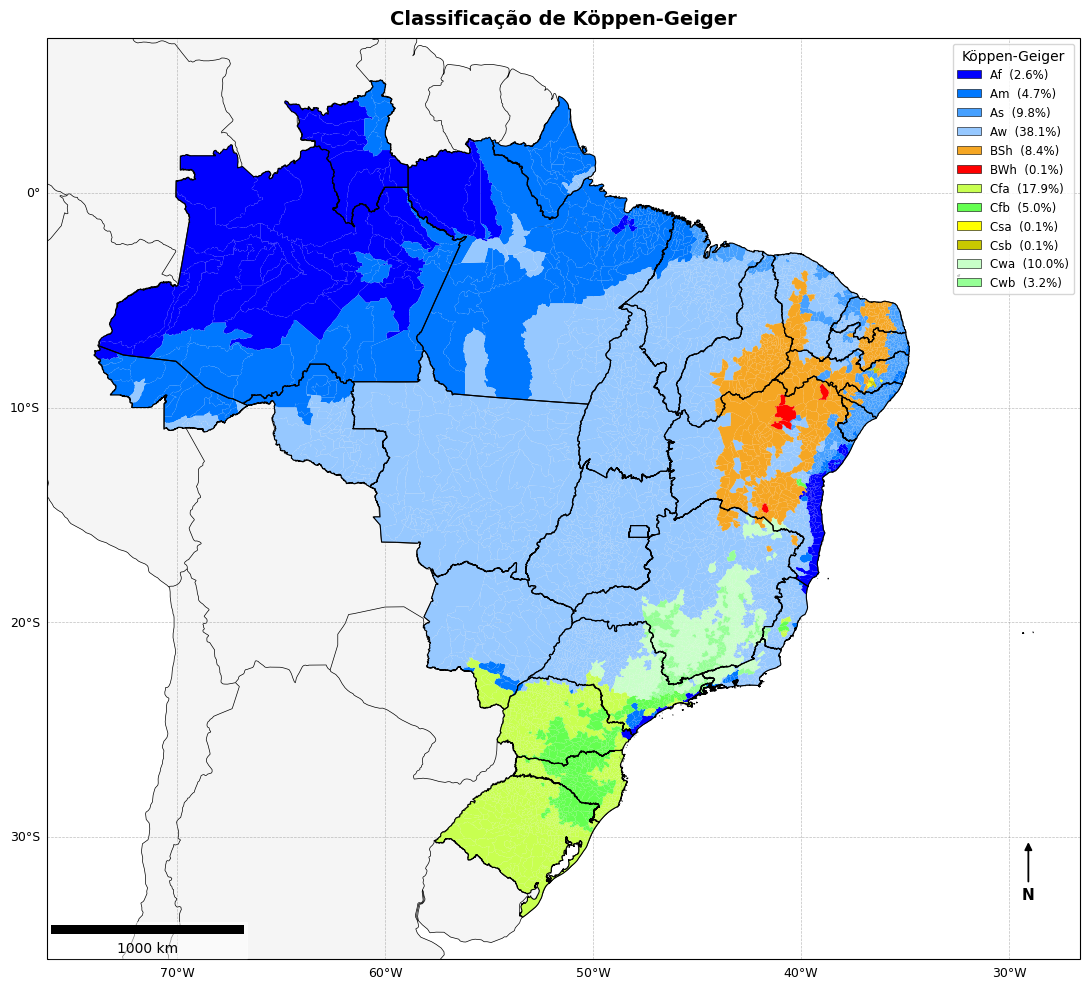

In [29]:
warnings.filterwarnings("ignore", category=DownloadWarning)
gdf_koppen_merged = municipios_gdf.merge(df_koppen, on='code_muni', how='left')
plot_koppen(gdf_koppen_merged)

# 6. Capítulo 2 — Precipitação

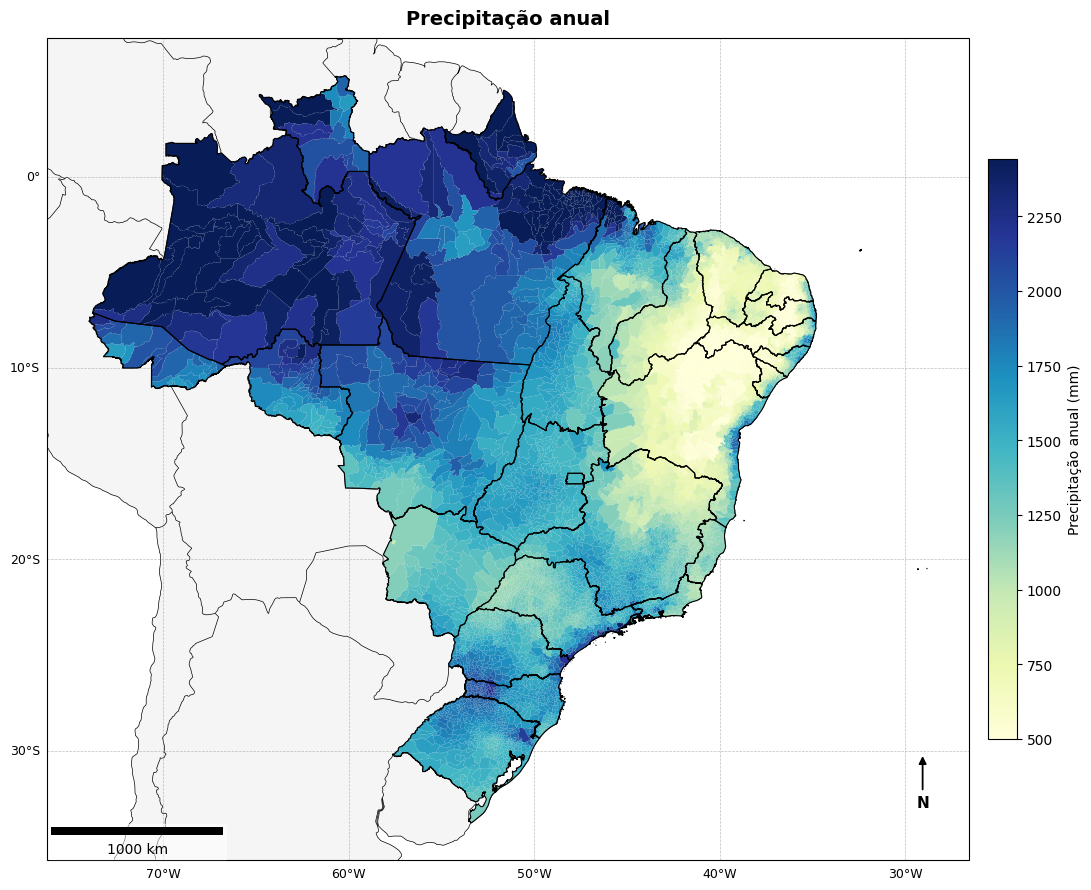

In [30]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_koppen_merged, 'precip_anual_mm', 'Precipitação anual',
              'mm', 'YlGnBu', 'precip_anual.png')

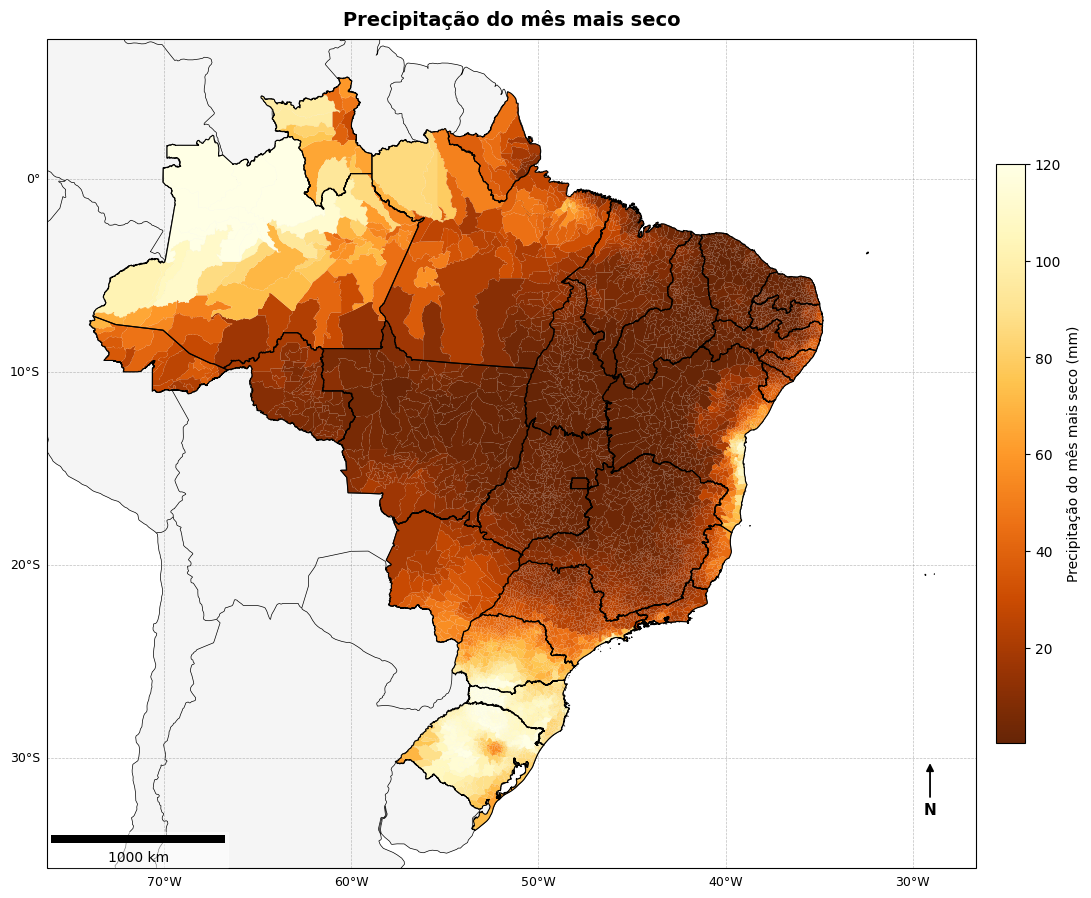

In [31]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_koppen_merged, 'precip_mes_mais_seco_mm', 'Precipitação do mês mais seco',
              'mm', 'YlOrBr_r', 'precip_mes_seco.png')

# 7. Capítulo 3 — Temperatura

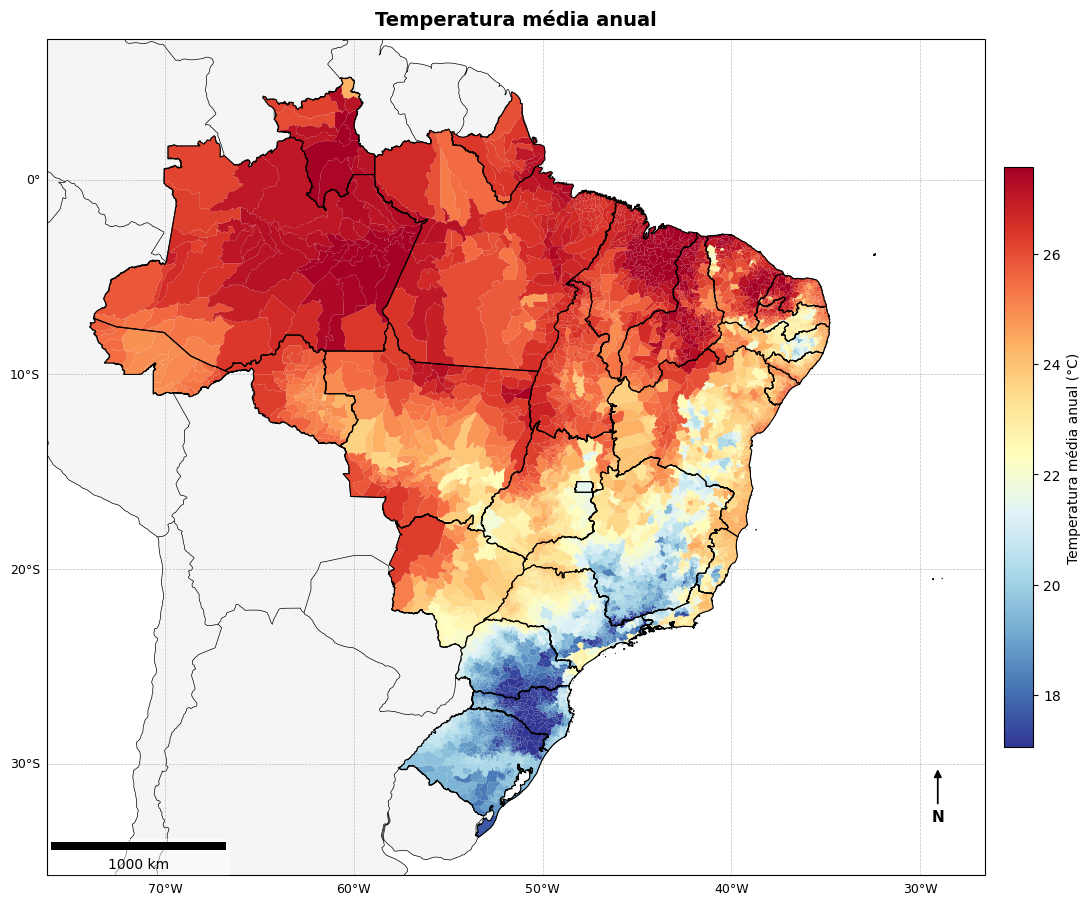

In [32]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_koppen_merged, 'temp_anual_c', 'Temperatura média anual',
              '°C', 'RdYlBu_r', 'temp_anual.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_koppen_merged, 'temp_mes_mais_frio_c', 'Temperatura do mês mais frio',
              '°C', 'RdYlBu_r', 'temp_mes_frio.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_koppen_merged, 'temp_mes_mais_quente_c', 'Temperatura do mês mais quente',
              '°C', 'RdYlBu_r', 'temp_mes_quente.png')